# Maritime Tracker: Evaluate Rich Telemetry LSTM
This notebook loads the `rich_lstm_tracker.pth` weights and evaluates the 12-feature model on the test data to see if the ego-motion data mathematically improved the pixel tracking accuracy.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 1. Load Data & Convert to Velocities
Just like training, we convert `[x,y]` to `[dx,dy]` but leave all other 10 features identical.

In [2]:
# Load the 12-feature data
raw_train = np.load('../data/sequences_rich_train.npy')
raw_test = np.load('../data/sequences_rich_test.npy')

def extract_velocities(data):
    vels = np.zeros_like(data)
    vels[:, 1:, 0] = data[:, 1:, 0] - data[:, :-1, 0] # dx
    vels[:, 1:, 1] = data[:, 1:, 1] - data[:, :-1, 1] # dy
    vels[:, :, 2:] = data[:, :, 2:] # Copy all other 10 features
    return vels[:, 1:, :] # Drop frame 0

train_data = extract_velocities(raw_train)
test_data = extract_velocities(raw_test)

# Fit Scaler on Training Data
scaler = StandardScaler()
N_train, seq_len, features = train_data.shape
scaler.fit(train_data.reshape(-1, features))

# Scale Test Data
test_scaled_flat = scaler.transform(test_data.reshape(-1, features))
test_scaled = test_scaled_flat.reshape(test_data.shape[0], seq_len, features)

print("Test Data Normalized!")

FileNotFoundError: [Errno 2] No such file or directory: '../data/sequences_rich_train.npy'

### 2. Define Rich LSTM & Load Weights

In [ ]:
class RichLSTMTracker(nn.Module):
    def __init__(self, input_size=12, hidden_size=128, num_layers=2):
        super(RichLSTMTracker, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=False)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 4) # Output is still 4
        )
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :] 
        return self.fc(last_time_step)

model = RichLSTMTracker().to(device)

weight_path = '../models/rich_lstm_tracker.pth'
if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print("Successfully loaded RICH weights!")
else:
    print(f"ERROR: Could not find {weight_path}")

model.eval()

Successfully loaded RICH weights!


RichLSTMTracker(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

### 3. Predict Velocities & Decode to Pixels
The model outputs `[dx, dy, w, h]` (in normalized space). We must inverse_transform it. Because our scaler expects 12 features, we pad the 4 predictions with 8 dummy variables to inverse_transform, then discard the dummy variables.

In [ ]:
X_test = torch.tensor(test_scaled[:, :-1, :], dtype=torch.float32).to(device)
with torch.no_grad():
    Y_pred_scaled = model(X_test).cpu().numpy() # Shape: (N, 4)

# To inverse transform, we must pad the predictions to length 12
Y_pred_padded = np.zeros((len(Y_pred_scaled), 12))
Y_pred_padded[:, :4] = Y_pred_scaled

Y_pred_vel = scaler.inverse_transform(Y_pred_padded)[:, :4] # Extract only the 4 values we care about

# DECODE VELOCITIES TO ABSOLUTE PIXELS
last_known_abs = raw_test[:, 9, :4]  # The last frame of history [x, y, w, h]
true_target_abs = raw_test[:, 10, :4] # The true next frame [x, y, w, h]

pred_target_abs = np.zeros_like(true_target_abs)
pred_target_abs[:, 0] = last_known_abs[:, 0] + Y_pred_vel[:, 0] # Pred X
pred_target_abs[:, 1] = last_known_abs[:, 1] + Y_pred_vel[:, 1] # Pred Y
pred_target_abs[:, 2] = Y_pred_vel[:, 2] # Pred W
pred_target_abs[:, 3] = Y_pred_vel[:, 3] # Pred H

print("Decoded predictions to absolute pixels successfully!")

Decoded predictions to absolute pixels successfully!


### 4. Final Pixel Error Distribution
Compare this histogram and Mean Pixel Error to the Vision-Only model!

Average Pixel Error: 2.26 pixels
Median Pixel Error: 1.51 pixels


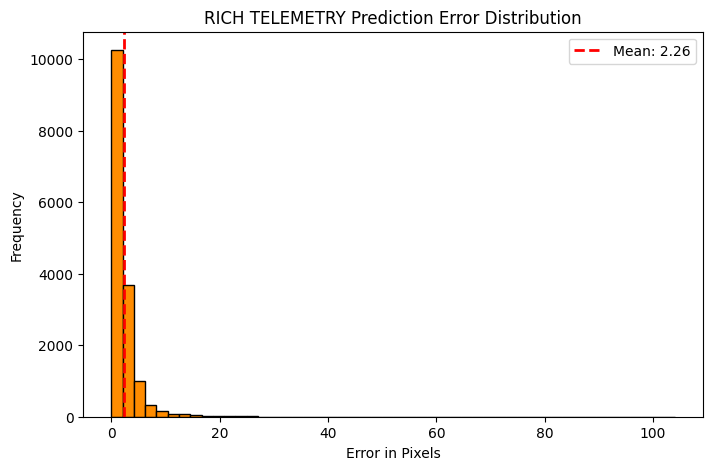

In [ ]:
# Calculate Euclidean pixel error of the centers
true_cx = true_target_abs[:, 0] + true_target_abs[:, 2]/2
true_cy = true_target_abs[:, 1] + true_target_abs[:, 3]/2

pred_cx = pred_target_abs[:, 0] + pred_target_abs[:, 2]/2
pred_cy = pred_target_abs[:, 1] + pred_target_abs[:, 3]/2

pixel_errors = np.sqrt((true_cx - pred_cx)**2 + (true_cy - pred_cy)**2)

print(f"Average Pixel Error: {np.mean(pixel_errors):.2f} pixels")
print(f"Median Pixel Error: {np.median(pixel_errors):.2f} pixels")

plt.figure(figsize=(8, 5))
plt.hist(pixel_errors, bins=50, color='darkorange', edgecolor='black')
plt.title("RICH TELEMETRY Prediction Error Distribution")
plt.xlabel("Error in Pixels")
plt.ylabel("Frequency")
plt.axvline(np.mean(pixel_errors), color='red', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(pixel_errors):.2f}')
plt.legend()
plt.show()

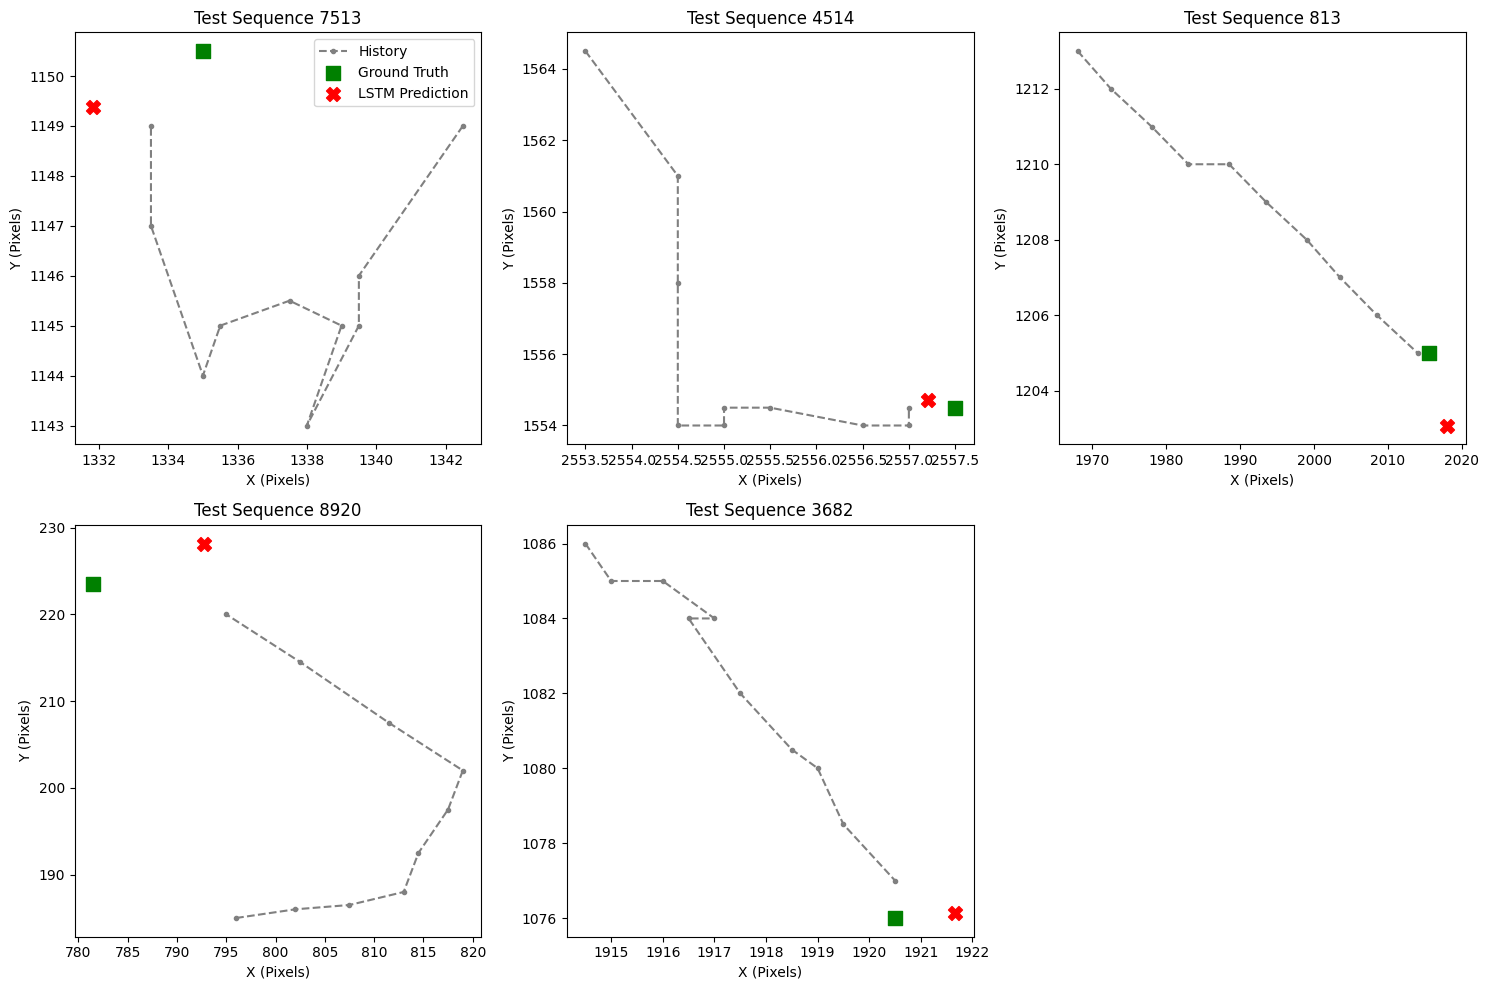

In [ ]:
num_plots = 5
indices = np.random.choice(len(raw_test), num_plots, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    plt.subplot(2, 3, i + 1)
    
    # Absolute history [x, y] for frames 0 to 9
    hist_x = raw_test[idx, :10, 0] + raw_test[idx, :10, 2]/2
    hist_y = raw_test[idx, :10, 1] + raw_test[idx, :10, 3]/2
    
    true_x = true_target_abs[idx, 0] + true_target_abs[idx, 2]/2
    true_y = true_target_abs[idx, 1] + true_target_abs[idx, 3]/2
    
    pred_x = pred_target_abs[idx, 0] + pred_target_abs[idx, 2]/2
    pred_y = pred_target_abs[idx, 1] + pred_target_abs[idx, 3]/2
    
    plt.plot(hist_x, hist_y, marker='.', color='gray', linestyle='dashed', label='History')
    plt.scatter(true_x, true_y, color='green', marker='s', s=100, label='Ground Truth')
    plt.scatter(pred_x, pred_y, color='red', marker='X', s=100, label='LSTM Prediction')
    
    plt.title(f"Test Sequence {idx}")
    plt.xlabel("X (Pixels)")
    plt.ylabel("Y (Pixels)")
    
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()